# Figure 1B. Comparing UHVDB to other human virome databases

### Inphared (NCBI phages)

In [ ]:
%%bash
### Inphared unique sequence count ###
mkdir -p inphared
cd inphared

# download seqs
wget https://millardlab-inphared.s3.climb.ac.uk/14Apr2025_genomes.fa.gz

### Trim DTRs
/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/bin/tr-trimmer \
    14Apr2025_genomes.fa.gz \
    --min-length 20 \
    --include-tr-info \
    > 14Apr2025_genomes.trtrimmer.fna

### Calculate sequence hashes
singularity exec -B /gscratch/ \
/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/.singularity-cache/community-cr-prod.seqera.io-docker-registry-v2-blobs-sha256-c0-c01afbd21a56c8c6e33e1bfa161f157d9b31f2307a0896f97515139f79fb9cd3-data.img \
seq-hasher \
    14Apr2025_genomes.trtrimmer.fna \
    --multi-kmer-hashing \
    --circular-kmers \
    --print-sequence \
    > 14Apr2025_genomes.seqhasher.tsv

### Count unique sequences
python /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/bin/uhvdb_unique_hash.py \
    --input_seqhash_tsv 14Apr2025_genomes.seqhasher.tsv \
    --input_uhvdb_seqhash_tsv '' \
    --output_combined_seqhash_tsv 14Apr2025_genomes_seqhasher.tsv \
    --output_new_unique_fna 14Apr2025_genomes_seqhasher.fna

In [1]:
### Load inphared data
# load table and treat all as complete
import polars as pl

db_sizes = []

db_sizes.append({
    'database': 'Inphared',
    'Complete': pl.read_csv('inphared/14Apr2025_genomes_seqhasher.tsv', separator='\t', columns=['original_id', 'hash']).unique('hash').height,
    'High-quality': 0
})

### CHVD

In [2]:
### CHVD size estimate
# already dereplicated at vOTU level
# !wget https://zenodo.org/records/4776317/files/HV3_table2_master_table.xlsx?download=1 -O chvd/HV3_table2_master_table.xlsx

import polars as pl

chvd = pl.read_excel('chvd/HV3_table2_master_table.xlsx')

db_sizes.append({
    'database': 'CHVD',
    'Complete': chvd.filter(pl.col('CheckV_estimated_completeness') == 100).shape[0],
    'High-quality': chvd.filter(pl.col('CheckV_estimated_completeness') >= 90).shape[0],
})

### MMGE

In [4]:
%%bash 
### MMGE download

# mkdir -p mmge
# cd mmge

# wget wget https://mai.fudan.edu.cn/mgedb/client/file/all_mge_inf.zip
# unzip all_mge_inf.zip

# wget https://mai.fudan.edu.cn/mgedb/client/file/all_mge_seq.zip
# unzip all_mge_seq.zip

In [3]:
### MMGE extract HQ virus seqs
import polars as pl

mmge = pl.read_csv('mmge/all_mge_inf.csv')

(
    mmge
        .filter(
            (pl.col('status').str.contains('phage')) &
            (pl.col('checkv_genome_quality').is_in(['High-quality', 'Complete']))
        )[['MGEs_id']]
        # .write_csv('mmge/mmge_hq_virus_ids.txt', include_header=False)
)

MGEs_id
str
"""SRR5091468_141_108122_round347…"
"""ERR1190574_119_92848_round8-12…"
"""k141_1238_round8-12~2593911"""
"""k141_87509_round347~3711955"""
"""k141_140161_round347~3713420"""
…
"""ERR1305879_119_166149_round347…"
"""k99_23614_round8-12~2821696"""
"""SRR3582148_119_63067_round8-12…"


In [ ]:
%%bash
### MMGE genomovar clustering
cd mmge/

### extract HQ viruses seqs
seqkit grep \
    all_mge_seq.fasta \
    --pattern-file mmge_hq_virus_ids.txt \
    -o mmge_hq_viruses.fna

### Trim DTRs
/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/bin/tr-trimmer \
    mmge_hq_viruses.fna \
    --min-length 20 \
    --include-tr-info \
    > mmge_hq_viruses.trtrimmer.fna

### Calculate sequence hashes
singularity exec -B /gscratch/ \
/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/.singularity-cache/community-cr-prod.seqera.io-docker-registry-v2-blobs-sha256-c0-c01afbd21a56c8c6e33e1bfa161f157d9b31f2307a0896f97515139f79fb9cd3-data.img \
seq-hasher \
    mmge_hq_viruses.trtrimmer.fna \
    --multi-kmer-hashing \
    --circular-kmers \
    --print-sequence \
    > mmge_hq_viruses.seqhasher.tsv

### Count unique sequences
python /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/bin/uhvdb_unique_hash.py \
    --input_seqhash_tsv mmge_hq_viruses.seqhasher.tsv \
    --input_uhvdb_seqhash_tsv '' \
    --output_combined_seqhash_tsv mmge_hq_viruses_seqhasher.tsv \
    --output_new_unique_fna mmge_hq_viruses_seqhasher.fna

In [4]:
### MMGE size estimate
mmge_reps = set(pl.read_csv('mmge/mmge_hq_viruses_seqhasher.tsv', separator='\t', columns=['original_id', 'hash']).unique('hash')['original_id'])
db_sizes.append({
    'database': 'mMGE',
    'Complete': mmge.filter((pl.col('checkv_genome_quality') == 'Complete') & (pl.col('MGEs_id').is_in(mmge_reps))).shape[0],
    'High-quality': mmge.filter((pl.col('checkv_genome_quality') == 'High-quality') & (pl.col('MGEs_id').is_in(mmge_reps))).shape[0],
})

### UHGV

In [ ]:
%%bash
### Identify unique UHGV sequences
wget https://portal.nersc.gov/cfs/m342/UHGV/metadata/uhgv_metadata.tsv

### Identify HQ HC viruses
wget https://portal.nersc.gov/cfs/m342/UHGV/genome_catalogs/uhgv_hq_plus.fna.gz

### Trim DTRs
/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/bin/tr-trimmer \
    ../uhgv_hq_plus.fna.gz \
    --min-length 20 \
    --include-tr-info \
    > uhgv_hq_plus.trtrimmer.fna

### Calculate sequence hashes
singularity exec -B /gscratch/ \
/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/.singularity-cache/community-cr-prod.seqera.io-docker-registry-v2-blobs-sha256-c0-c01afbd21a56c8c6e33e1bfa161f157d9b31f2307a0896f97515139f79fb9cd3-data.img \
seq-hasher \
    uhgv_hq_plus.trtrimmer.fna \
    --multi-kmer-hashing \
    --circular-kmers \
    --print-sequence \
    > uhgv_hq_plus.seqhasher.tsv

### Count unique sequences
python /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/bin/uhvdb_unique_hash.py \
    --input_seqhash_tsv uhgv_hq_plus.seqhasher.tsv \
    --input_uhvdb_seqhash_tsv '' \
    --output_combined_seqhash_tsv uhgv_hq_plus_seqhasher.tsv \
    --output_new_unique_fna uhgv_hq_plus_seqhasher.fna

In [5]:
### UHGV size estimate
uhgv = pl.read_csv('uhgv_metadata.tsv', separator='\t', columns=['uhgv_genome', 'checkv_quality', 'viral_confidence'])

uhgv_reps = set(pl.read_csv('uhgv/uhgv_hq_plus_seqhasher.tsv', separator='\t').unique('hash')['original_id'])

db_sizes.append({
    'database': 'UHGV',
    'Complete': uhgv.filter((pl.col('checkv_quality') == 'Complete')  & (pl.col('uhgv_genome').is_in(uhgv_reps))).shape[0],
    'High-quality': uhgv.filter((pl.col('checkv_quality') == 'High-quality') & (pl.col('uhgv_genome').is_in(uhgv_reps))).shape[0],
})

In [6]:
### IMGVR extract HQ human virus seqs
imgvr_human = (
    pl.read_csv('IMGVR_all_Sequence_information.tsv', separator='\t', columns=['UVIG', 'Topology', 'Ecosystem classification', 'MIUViG quality'])
        .filter(
            (pl.col('Ecosystem classification').str.contains('Human')) &
            (pl.col('MIUViG quality').is_in(['High-quality', 'Complete']))
        )
)
# imgvr_human[['UVIG']].write_csv('imgvr/imgvr_human_hq_plus_ids.txt', include_header=False)

In [ ]:
%%bash
mkdir -p imgvr

# extract HQ seqs
wget https://portal.nersc.gov/genomad/__data__/IMGVR_DATA/IMGVR4_SEQUENCES.fna
seqkit grep \
    /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/analyses/uhvdb/mine/imgvr/IMGVR4_human_sequences.fna.gz \
    --id-regexp "^(.*?)\|" \
    --pattern-file imgvr/imgvr_human_hq_plus_ids.txt \
    --out-file imgvr/imgvr_human_hq_plus.fna.gz

In [ ]:
%%bash
cd imgvr/

### Trim DTRs
/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/bin/tr-trimmer \
    imgvr_human_hq_plus.fna.gz \
    --min-length 20 \
    --include-tr-info \
    > imgvr_human_hq_plus.trtrimmer.fna

### Calculate sequence hashes
singularity exec -B /gscratch/ \
/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases/.singularity-cache/community-cr-prod.seqera.io-docker-registry-v2-blobs-sha256-c0-c01afbd21a56c8c6e33e1bfa161f157d9b31f2307a0896f97515139f79fb9cd3-data.img \
seq-hasher \
    imgvr_human_hq_plus.trtrimmer.fna \
    --multi-kmer-hashing \
    --circular-kmers \
    --print-sequence \
    > imgvr_human_hq_plus.seqhasher.tsv

### Count unique sequences
python /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/bin/uhvdb_unique_hash.py \
    --input_seqhash_tsv imgvr_human_hq_plus.seqhasher.tsv \
    --input_uhvdb_seqhash_tsv '' \
    --output_combined_seqhash_tsv imgvr_human_hq_plus_seqhasher.tsv \
    --output_new_unique_fna imgvr_human_hq_plus_seqhasher.fna

In [7]:
### IMGVR size estimate
imgvr_reps = set(
    pl.read_csv('imgvr/imgvr_human_hq_plus_seqhasher.tsv', separator='\t')
        .unique('hash')
        .with_columns([
            pl.col('original_id').str.split('|').list[0]
        ])
        ['original_id']
)

db_sizes.append({
    'database': 'IMGVR',
    'Complete': imgvr_human.filter((pl.col('Topology') == 'Direct terminal repeat') & (pl.col('UVIG').is_in(imgvr_reps))).shape[0],
    'High-quality': imgvr_human.filter((pl.col('Topology') != 'Direct terminal repeat') & (pl.col('UVIG').is_in(imgvr_reps))).shape[0],
})

In [8]:
### UHVDB size estimate
import polars as pl
import glob

# filter mine report to only those in final uhvdb
uhvdb_seqhash = (
    pl.read_csv('uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/hq_hc_viruses_seqhasher.tsv.gz', separator='\t')
)

uhvdb_original_hash = (
    pl.concat([
        pl.read_csv('uhvdb_human_metag_results/2026-03-26-2_outputs/dereplicate/new_hq_hc_viruses_mapping.tsv.gz', separator='\t'),
        pl.read_csv('uhvdb_virus_db_results/uhvdb_2026-03-26/uhvdb_mapping.tsv.gz', separator='\t')
    ])
    .join(uhvdb_seqhash, on='original_id', how='inner')
)

df_lst = []
for file in glob.glob('*_results/*_outputs/dereplicate/new_uhvdb_classify.tsv.gz'):
    df = pl.read_csv(file, separator='\t', columns=['uhvdb_id', 'completeness_method'])
    df_lst.append(df)

combined_df = (
    pl.concat(df_lst)
        .join(uhvdb_original_hash, left_on='uhvdb_id', right_on='new_id', how='inner').unique('hash')
)

db_sizes.append({
    'database': 'UHVDB',
    'Complete': combined_df.filter(pl.col('completeness_method').str.contains('DTR')).height,
    'High-quality': combined_df.filter(~pl.col('completeness_method').str.contains('DTR')).height,
})

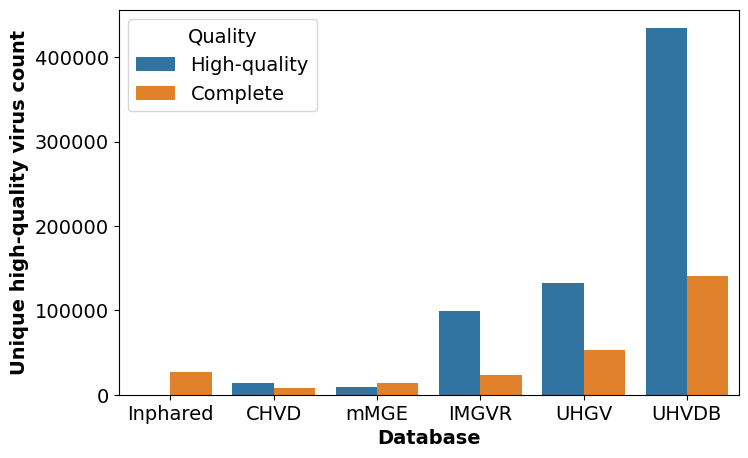

In [14]:
import seaborn as sns
import polars as pl
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

plot_df = (
    pl.DataFrame(db_sizes)
        .rename({'database':'Database'})
        .unpivot(
            ['Complete', 'High-quality'],
            index='Database',
            variable_name='Quality',
            value_name='Sequence count'
        )
)

plt.figure(figsize=(8,5))
sns.barplot(
    data=plot_df,
    x='Database',
    hue='Quality',
    y='Sequence count',
    order=['Inphared', 'CHVD', 'mMGE', 'IMGVR', 'UHGV', 'UHVDB'],
    hue_order=['High-quality', 'Complete'],
 )
plt.ylabel('Unique high-quality virus count', fontdict={'fontweight': 'bold'})
plt.xlabel('Database', fontdict={'fontweight': 'bold'})
plt.show()

In [10]:
db_sizes

[{'database': 'Inphared', 'Complete': 26848, 'High-quality': 0},
 {'database': 'CHVD', 'Complete': 7847, 'High-quality': 14034},
 {'database': 'mMGE', 'Complete': 14315, 'High-quality': 8740},
 {'database': 'UHGV', 'Complete': 53107, 'High-quality': 132977},
 {'database': 'IMGVR', 'Complete': 23111, 'High-quality': 99106},
 {'database': 'UHVDB', 'Complete': 140818, 'High-quality': 434679}]